In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor,plot_tree
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score

assessed_value_df = pd.read_csv("data_raw/Assessed_Values.csv")
family_improvement_df = pd.read_csv("data_raw/Family_Improvement_Characteristics.csv")
parcel_universe_df = pd.read_csv("data_raw/Parcel_Universe.csv")




FileNotFoundError: [Errno 2] No such file or directory: 'Assessed_Values.csv'

In [ ]:
assessed_value_df = assessed_value_df[
    ["pin", "tax_year", "certified_bldg", "certified_land", "certified_tot"]
].copy()

assessed_value_df = assessed_value_df.rename(columns={
    "certified_bldg": "improvement_av",
    "certified_land": "land_av",
    "certified_tot": "tav"
})
family_improvement_df = family_improvement_df[
    [
        "pin", "tax_year", "year_built", "building_sqft", "land_sqft",
        "num_bedrooms", "num_rooms", "num_full_baths", "num_half_baths",
        "type_of_residence", "construction_quality", "garage_size",
        "basement_type", "ext_wall_material", "central_heating",
        "repair_condition", "roof_material", "central_air",
       "site_desirability", "single_v_multi_family"
    ]
].copy()
parcel_universe_df = parcel_universe_df[
   ["pin", "tax_year", "municipality_name", "township_name", "neighborhood_code"]
   ].copy()
parcel_universe_df = parcel_universe_df[
   ["pin", "tax_year", "municipality_name", "township_name", "neighborhood_code"]
   ].copy()

print(assessed_value_df.columns.tolist())
print(family_improvement_df.columns.tolist())
print(parcel_universe_df.columns.tolist())


['pin', 'tax_year', 'improvement_av', 'land_av', 'tav']
['pin', 'tax_year', 'year_built', 'building_sqft', 'land_sqft', 'num_bedrooms', 'num_rooms', 'num_full_baths', 'num_half_baths', 'type_of_residence', 'construction_quality', 'garage_size', 'basement_type', 'ext_wall_material', 'central_heating', 'repair_condition', 'roof_material', 'central_air', 'site_desirability', 'single_v_multi_family']
['pin', 'tax_year', 'municipality_name', 'township_name', 'neighborhood_code']


In [ ]:
df = assessed_value_df.merge(
    family_improvement_df,
    on = ["pin","tax_year"],
    how = "inner"
)
df = df.merge(
    parcel_universe_df,
    on = ["pin","tax_year"],
    how = "left"
)
print(df)

                     pin  tax_year  improvement_av  land_av     tav  \
0         32213210090000      2020          2287.0   1007.0  3294.0   
1         29052010120000      2016          3962.0   1950.0  5912.0   
2         29054010360000      2016          4585.0   1296.0  5881.0   
3         29054110460000      2016          5578.0   1665.0  7243.0   
4         29054150290000      2016          4178.0   1218.0  5396.0   
...                  ...       ...             ...      ...     ...   
30656599  33323020090000      2026             NaN      NaN     NaN   
30656600  33323020100000      2026             NaN      NaN     NaN   
30656601  33323020110000      2026             NaN      NaN     NaN   
30656602  33323020130000      2026             NaN      NaN     NaN   
30656603  33323020150000      2026             NaN      NaN     NaN   

          year_built  building_sqft  land_sqft  num_bedrooms  num_rooms  ...  \
0             1897.0          740.0     3100.0           2.0       

In [ ]:
print("Unique pin-tax_year pairs:", df[["pin","tax_year"]].drop_duplicates().shape[0])
dup_count = df.duplicated(subset=["pin","tax_year"]).sum()
print("Duplicated pin-tax_year rows:", dup_count)

Unique pin-tax_year pairs: 30404176
Duplicated pin-tax_year rows: 252428


In [ ]:
print(df["tax_year"].value_counts().sort_index())
print(df["type_of_residence"].value_counts(dropna=False).head(20))
print(df["single_v_multi_family"].value_counts(dropna=False))

tax_year
1999    1059702
2000    1077974
2001    1078943
2002    1081888
2003    1085833
2004    1089761
2005    1093404
2006    1096341
2007    1098544
2008    1099960
2009    1099466
2010    1099597
2011    1099010
2012    1098752
2013    1098025
2014    1097705
2015    1098115
2016    1098108
2017    1098637
2018    1098786
2019    1098966
2020    1099085
2021    1099631
2022    1100288
2023    1101227
2024    1102657
2025    1103022
2026    1103177
Name: count, dtype: int64
type_of_residence
1 Story        12638060
2 Story        11404096
1.5 Story       2849163
Split Level     2738991
3 Story +        963140
NaN               63154
Name: count, dtype: int64
single_v_multi_family
Single-Family    25837139
Multi-Family      4755157
NaN                 64308
Name: count, dtype: int64


In [ ]:
model_df = df.copy()

train_df = model_df[model_df["tax_year"] == 2024].copy()
pred_2025_df = model_df[model_df["tax_year"] == 2025].copy()

train_df = train_df[train_df["tav"].notna() & (train_df["tav"] > 0)].copy()
pred_2025_df = pred_2025_df[pred_2025_df["land_av"].notna() & (pred_2025_df["land_av"] > 0)].copy()

train_df = train_df.drop_duplicates(subset = ["pin","tax_year"])
print("train_df_shape:", train_df.shape)
print("pred_2025_df shape:", pred_2025_df.shape)


drop_cols = ["tav","land_av","improvement_av","pin"]

X_train_raw = train_df.drop(columns=drop_cols, errors = "ignore").copy()
y_train_full = train_df["tav"].copy()

X_2025_raw = pred_2025_df.drop(columns=drop_cols, errors= "ignore").copy()

X_train_raw = X_train_raw.drop(columns = ["tax_year","neighborhood_code"], errors="ignore")
X_2025_raw = X_2025_raw.drop(columns=["tax_year","neighborhood_code"], errors="ignore")

print("X_train_raw shape:", X_train_raw.shape)
print("X_2025_raw shape:", X_2025_raw.shape)
print("Same columns in train and 2025:", set(X_train_raw.columns) == set(X_2025_raw.columns))

num_cols = X_train_raw.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train_raw.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

train_medians = X_train_raw[num_cols].median()

X_train_raw[num_cols] = X_train_raw[num_cols].fillna(train_medians)
X_2025_raw[num_cols] = X_2025_raw[num_cols].fillna(train_medians)

X_train_raw[cat_cols] = X_train_raw[cat_cols].fillna("Unknown")
X_2025_raw[cat_cols] = X_2025_raw[cat_cols].fillna("Unknown")

print("Missing in X_train_raw:", X_train_raw.isna().sum())
print("Missing in X_2025_raw:", X_2025_raw.isna().sum())

train_df_shape: (1093203, 26)
pred_2025_df shape: (1101418, 26)
X_train_raw shape: (1093203, 20)
X_2025_raw shape: (1101418, 20)
Same columns in train and 2025: True
Numeric columns: ['year_built', 'building_sqft', 'land_sqft', 'num_bedrooms', 'num_rooms', 'num_full_baths', 'num_half_baths']
Categorical columns: ['type_of_residence', 'construction_quality', 'garage_size', 'basement_type', 'ext_wall_material', 'central_heating', 'repair_condition', 'roof_material', 'central_air', 'site_desirability', 'single_v_multi_family', 'municipality_name', 'township_name']


/var/folders/rz/k5670s215l70_htccm0pcs5m0000gn/T/ipykernel_52964/175700425.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=["object"]).columns.tolist()


Missing in X_train_raw: year_built               0
building_sqft            0
land_sqft                0
num_bedrooms             0
num_rooms                0
num_full_baths           0
num_half_baths           0
type_of_residence        0
construction_quality     0
garage_size              0
basement_type            0
ext_wall_material        0
central_heating          0
repair_condition         0
roof_material            0
central_air              0
site_desirability        0
single_v_multi_family    0
municipality_name        0
township_name            0
dtype: int64
Missing in X_2025_raw: year_built               0
building_sqft            0
land_sqft                0
num_bedrooms             0
num_rooms                0
num_full_baths           0
num_half_baths           0
type_of_residence        0
construction_quality     0
garage_size              0
basement_type            0
ext_wall_material        0
central_heating          0
repair_condition         0
roof_material         

In [ ]:
combined_X = pd.concat([X_train_raw,X_2025_raw], axis = 0)
combined_X = pd.get_dummies(combined_X, drop_first=True)

n_train = X_train_raw.shape[0]

X_train_full = combined_X.iloc[:n_train,:].copy()
X_2025 = combined_X.iloc[n_train:,:].copy()


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
ridge_cv = RidgeCV(alphas=[0.1,1,10,100], cv = 5)
ridge_cv.fit(X_train_full,y_train_full)

print("Best alpha:", ridge_cv.alpha_)

depths = [6,8,10,12,14,16]
for d in depths:
    tree = DecisionTreeRegressor(
        max_depth = d,
        min_samples_split = 20,
        min_samples_leaf = 10,
        random_state = 0
    )
    scores = cross_val_score(tree, X_train_full, y_train_full, cv = 5, scoring = "r2")
    print(f"Depth {d}, Mean R2: {scores.mean():.4f}")

Best alpha: 10.0
Depth 6, Mean R2: 0.3472
Depth 8, Mean R2: 0.3859
Depth 10, Mean R2: 0.4061
Depth 12, Mean R2: 0.4170
Depth 14, Mean R2: 0.4231
Depth 16, Mean R2: 0.4227


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X_train_full,y_train_full, test_size=0.2, random_state=0)
# Ridge:
alphas = [0.1,1,10,100]
ridge_results = []
for alpha in alphas:
    ridge = Ridge(alpha)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred_ridge))
    mae = mean_absolute_error(y_test,y_pred_ridge)
    r2 = r2_score(y_test,y_pred_ridge)

    ridge_results.append([alpha, rmse, mae,r2])

ridge_df = pd.DataFrame(ridge_results, columns=["alpha","RMSE","MAE","R2_score"])
print("Ridge:")
print(ridge_df)


# Elastic Net:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet.fit(X_train,y_train)
y_pred_enet = enet.predict(X_test)

enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_enet))
enet_mae = mean_absolute_error(y_test, y_pred_enet)
enet_r2 = r2_score(y_test,y_pred_enet)

print("Elastic Net:")
print("Enet RMSE:", enet_rmse)
print("Enet mae:", enet_mae)
print("Enet R2:", enet_r2)

# Tree Decision
depth = [2,4,6,8,10,12,14,16,20]
tree_results = []

for d in depth:
    tree = DecisionTreeRegressor(
        max_depth = d,
        min_samples_split = 20,
        min_samples_leaf = 10,
        random_state = 0
)
    tree.fit(X_train,y_train)
    y_pred_tree = tree.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
    mae = mean_absolute_error(y_test, y_pred_tree)
    r2 = r2_score(y_test, y_pred_tree)

    tree_results.append([d, rmse, mae, r2])
tree_df = pd.DataFrame(tree_results, columns=["max_depth","RMSE","MAE","R2_score"])
print("Decision Tree:")
print(tree_df)

Ridge:
   alpha          RMSE           MAE  R2_score
0    0.1  25301.692259  13398.324612  0.422090
1    1.0  25302.968918  13398.550857  0.422031
2   10.0  25310.831871  13399.667739  0.421672
3  100.0  25321.121242  13397.656322  0.421202
Elastic Net:
Enet RMSE: 25685.623980440338
Enet mae: 13300.746295630968
Enet R2: 0.40441790255993304
Decision Tree:
   max_depth          RMSE           MAE  R2_score
0          2  28361.974140  14583.617480  0.273837
1          4  26214.153710  13536.633631  0.379655
2          6  24297.312312  12586.391786  0.467061
3          8  23159.339367  11963.966858  0.515812
4         10  22162.835574  11461.716898  0.556583
5         12  21814.633561  11116.089942  0.570407
6         14  21645.491330  10821.213178  0.577043
7         16  21591.896348  10619.516257  0.579135
8         20  21750.999370  10469.525959  0.572910


In [ ]:
best_model = DecisionTreeRegressor(
    max_depth =14,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=0
)

best_model.fit(X_train_full,y_train_full)
pred_2025_df["pred_tav_2025"] = best_model.predict(X_2025)
pred_2025_df["pred_tav_2025"] = pred_2025_df["pred_tav_2025"].clip(lower=0)

                                    Feature  Importance
1                             building_sqft    0.572493
48      single_v_multi_family_Single-Family    0.090167
0                                year_built    0.081217
5                            num_full_baths    0.069944
2                                 land_sqft    0.062817
9               type_of_residence_3 Story +    0.027962
43               central_air_No Central A/C    0.013271
46  site_desirability_Not Relevant To Value    0.013258
38          roof_material_Shingle + Asphalt    0.011771
6                            num_half_baths    0.007682


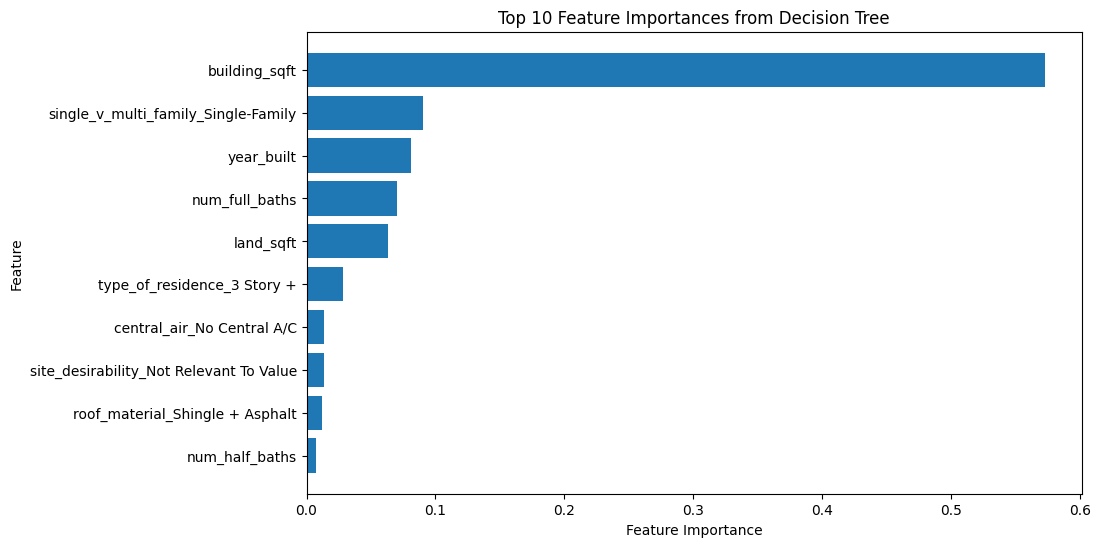

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X_train_full.columns,
    "Importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values("Importance",ascending = False)
top_importance = importance_df.head(10)

print(top_importance)

plt.figure(figsize =(10,6))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances from Decision Tree")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
current_rate_2025 = 0.02
pred_2025_df["tax_current_2025"] = current_rate_2025 * pred_2025_df["pred_tav_2025"]

new_land_rate_2025 = pred_2025_df["tax_current_2025"].sum() / pred_2025_df["land_av"].sum()

pred_2025_df["tax_land_only_2025"] = new_land_rate_2025 * pred_2025_df["land_av"]
pred_2025_df["tax_diff_2025"] = pred_2025_df["tax_land_only_2025"] - pred_2025_df["tax_current_2025"]
print("Revenue-neutral land-only rate for 2025:", new_land_rate_2025)
print("Share paying less:", (pred_2025_df["tax_diff_2025"] < 0).mean())
print("Share paying more:", (pred_2025_df["tax_diff_2025"] > 0).mean())
print(pred_2025_df["tax_diff_2025"].describe())

Revenue-neutral land-only rate for 2025: 0.07986750840646571
Share paying less: 0.6260892776402782
Share paying more: 0.3739107223597217
count    1.101418e+06
mean    -4.058721e-14
std      1.038190e+03
min     -4.209608e+04
25%     -2.742296e+02
50%     -1.058248e+02
75%      1.548471e+02
max      5.053482e+05
Name: tax_diff_2025, dtype: float64


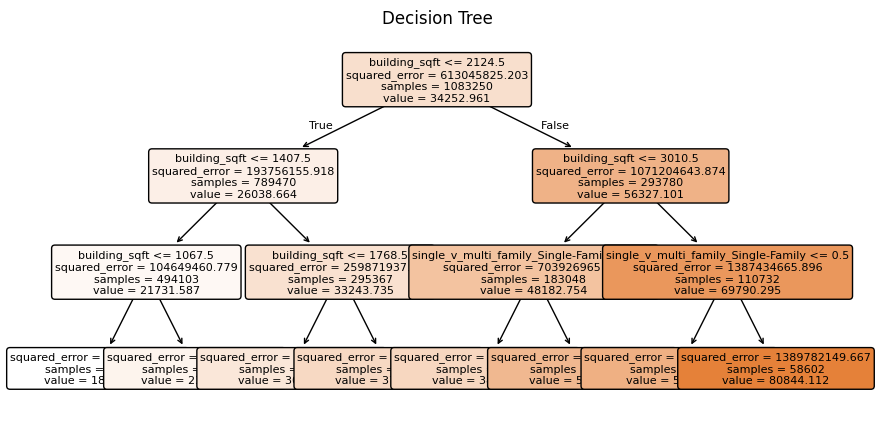

In [ ]:
selected_features = [
    "building_sqft",
    "single_v_multi_family_Single-Family",
    "year_built",
    "land_sqft",
    "num_full_baths"
]

Xy_small = X_train_full[selected_features].copy()
Xy_small["tav"] = y_train_full.values

sqft_cut = Xy_small["building_sqft"].quantile(0.995)
tav_cut = Xy_small["tav"].quantile(0.995)


Xy_small = Xy_small[
    (Xy_small["building_sqft"] <= sqft_cut) & (Xy_small["tav"] <= tav_cut)
].copy()

Xy_small_clean = Xy_small[selected_features]
y_small_clean = Xy_small["tav"]
small_tree = DecisionTreeRegressor(max_depth = 3, random_state=0)
small_tree.fit(Xy_small_clean,y_small_clean)



plt.figure(figsize=(10,5))
plot_tree(
    small_tree,
    feature_names= selected_features,
    filled = True,
    rounded = True,
    fontsize=8
)
plt.title("Decision Tree")
plt.show()

In [ ]:
# I want to verify that all the new columns are present in pred_2025_df before I proceed with the distributional analysis. 
# So this is why I will print out whether each of the expected columns is in the DataFrame. 
# So that we will add missing variables to pred_2025_df before we do the distributional analysis.

check_cols = [
    "tax_current_2025",
    "tax_land_only_2025",
    "tax_diff_2025",
    "pct_change_2025",
    "helped_2025",
    "hurt_2025",
    "value_decile_2025"
]

for col in check_cols:
    print(col, col in pred_2025_df.columns)

tax_current_2025 True
tax_land_only_2025 True
tax_diff_2025 True
pct_change_2025 False
helped_2025 False
hurt_2025 False
value_decile_2025 False


In [ ]:
# Add missing distributional-analysis variables to pred_2025_df

dist_2025_df = pred_2025_df.copy() # To have a clean working copy of the DataFrame for distributional analysis (pred_2025_df)

pred_2025_df["pct_change_2025"] = (
    pred_2025_df["tax_diff_2025"] / pred_2025_df["tax_current_2025"]
)

pred_2025_df["helped_2025"] = (pred_2025_df["tax_diff_2025"] < 0).astype(int)
pred_2025_df["hurt_2025"] = (pred_2025_df["tax_diff_2025"] > 0).astype(int)

pred_2025_df["value_decile_2025"] = (
    pd.qcut(
        pred_2025_df["pred_tav_2025"],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1
)

print(pred_2025_df[[
    "tax_current_2025",
    "tax_land_only_2025",
    "tax_diff_2025",
    "pct_change_2025",
    "helped_2025",
    "hurt_2025",
    "value_decile_2025"
]].head())

        tax_current_2025  tax_land_only_2025  tax_diff_2025  pct_change_2025  \
114559        746.522395          605.874919    -140.647476        -0.188404   
114584        574.451963          632.550667      58.098704         0.101138   
190347        680.354499          834.934933     154.580434         0.227206   
190348        931.294231          603.798364    -327.495867        -0.351657   
190352       1660.879545         1043.708600    -617.170946        -0.371593   

        helped_2025  hurt_2025  value_decile_2025  
114559            1          0                  7  
114584            0          1                  6  
190347            0          1                  7  
190348            1          0                  9  
190352            1          0                 10  


In [ ]:
#  To verify that all new columns are present and results returned as expected

for col in check_cols:
    print(col, col in pred_2025_df.columns)

tax_current_2025 True
tax_land_only_2025 True
tax_diff_2025 True
pct_change_2025 True
helped_2025 True
hurt_2025 True
value_decile_2025 True


In [ ]:
# We can have the summary table by predicted 2025 value decile at first

decile_summary_2025 = (
    dist_2025_df.groupby("value_decile_2025")
    .agg(
        n_parcels=("pin", "count"),
        share_helped=("helped_2025", "mean"),
        share_hurt=("hurt_2025", "mean"),
        mean_tax_diff=("tax_diff_2025", "mean"),
        median_tax_diff=("tax_diff_2025", "median"),
        mean_pct_change=("pct_change_2025", "mean"),
        median_pct_change=("pct_change_2025", "median")
    )
    .reset_index()
)

print(decile_summary_2025)

   value_decile_2025  n_parcels  share_helped  share_hurt  mean_tax_diff  \
0                  1     110404      0.677792    0.322208      12.249922   
1                  2     110565      0.651002    0.348998      14.714242   
2                  3     109511      0.641744    0.358256       5.851422   
3                  4     114815      0.646222    0.353778      -7.933740   
4                  5     105845      0.578081    0.421919      25.488566   
5                  6     110812      0.598311    0.401689     -10.137501   
6                  7     128832      0.573499    0.426501      30.280179   
7                  8      90359      0.629179    0.370821     -23.502298   
8                  9     110259      0.643068    0.356932     -38.916237   
9                 10     110016      0.628772    0.371228     -16.090662   

   median_tax_diff  mean_pct_change  median_pct_change  
0       -70.802965         0.042231          -0.260649  
1       -91.186963         0.038519          -0.2

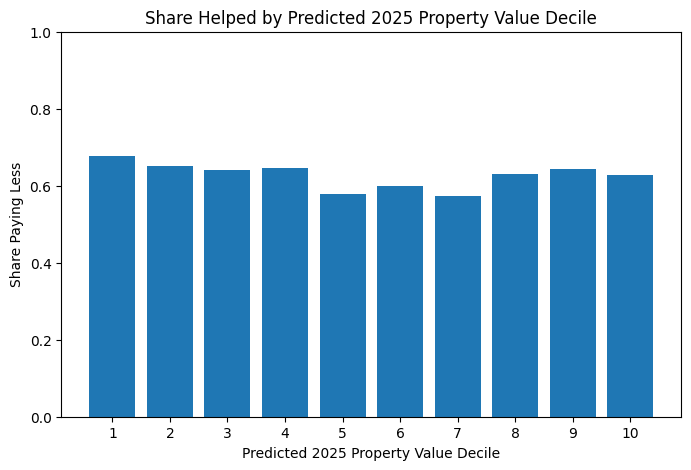

In [ ]:
# Plot 1 — Share helped by predicted 2025
# property value decile

plt.figure(figsize=(8, 5))
plt.bar(
    decile_summary_2025["value_decile_2025"],
    decile_summary_2025["share_helped"]
)
plt.xlabel("Predicted 2025 Property Value Decile")
plt.ylabel("Share Paying Less")
plt.title("Share Helped by Predicted 2025 Property Value Decile")
plt.ylim(0, 1)
plt.xticks(decile_summary_2025["value_decile_2025"])
plt.show()

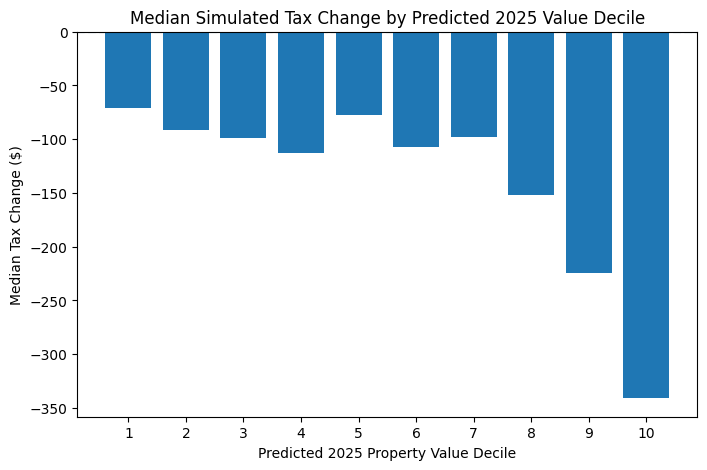

In [ ]:
# Plot 2 — Median tax change by predicted 2025
# 2025 property value decile

plt.figure(figsize=(8, 5))
plt.bar(
    decile_summary_2025["value_decile_2025"],
    decile_summary_2025["median_tax_diff"]
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted 2025 Property Value Decile")
plt.ylabel("Median Tax Change ($)")
plt.title("Median Simulated Tax Change by Predicted 2025 Value Decile")
plt.xticks(decile_summary_2025["value_decile_2025"])
plt.show()

Visualization range: -0.8703811506159304 to 2.81859333193278
Rows kept: 1079391 out of 1101418


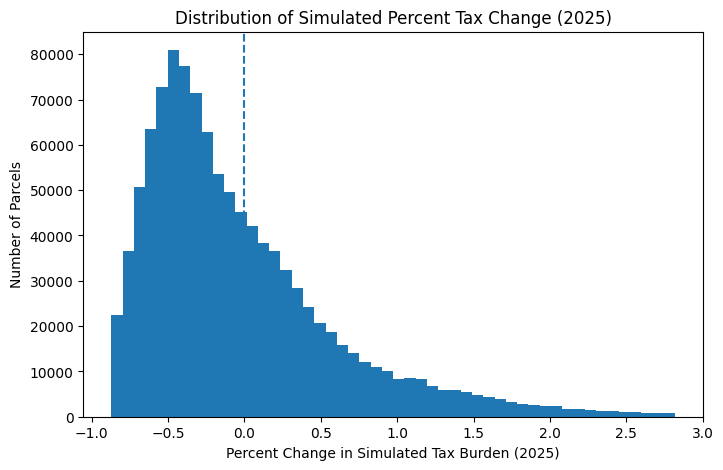

In [ ]:
# Plot 3 - Histogram of percent tax change

# Trim extreme 1% tails for visualization only (I want tokeep all data for summary tables and other analyses)
lower = dist_2025_df["pct_change_2025"].quantile(0.01)
upper = dist_2025_df["pct_change_2025"].quantile(0.99)

hist_df_2025 = dist_2025_df[
    (dist_2025_df["pct_change_2025"] >= lower) &
    (dist_2025_df["pct_change_2025"] <= upper)
].copy()

print("Visualization range:", lower, "to", upper)
print("Rows kept:", len(hist_df_2025), "out of", len(dist_2025_df))

plt.figure(figsize=(8, 5))
plt.hist(hist_df_2025["pct_change_2025"], bins=50)
plt.axvline(0, linestyle="--")
plt.xlabel("Percent Change in Simulated Tax Burden (2025)")
plt.ylabel("Number of Parcels")
plt.title("Distribution of Simulated Percent Tax Change (2025)")
plt.show()


In [ ]:
# Diagnose which subgroup column is available
# Check subgroup columns
# Plot 1 and Plot 2 already use a fixed grouping variable (value decile),
# and Plot 3 already uses a fixed analysis variable (pct_change).
# Plot 4 is different because it is a subgroup comparison plot.
# Therefore, before generating Plot 4, we first check which subgroup
# variable in the current dataset is actually usable, has low missingness,
# and provides meaningful interpretation.

candidate_cols = [
    "municipality_name",
    "neighborhood_code",
    "township_name",
    "type_of_residence",
    "single_v_multi_family"
]

for col in candidate_cols:
    if col in dist_2025_df.columns:
        print(f"{col}: exists")
        print("  missing share:", dist_2025_df[col].isna().mean())
        print("  sample values:", dist_2025_df[col].dropna().astype(str).unique()[:10])
        print()

municipality_name: exists
  missing share: 1.0
  sample values: <StringArray>
[]
Length: 0, dtype: str

neighborhood_code: exists
  missing share: 1.0
  sample values: <StringArray>
[]
Length: 0, dtype: str

township_name: exists
  missing share: 1.0
  sample values: <StringArray>
[]
Length: 0, dtype: str

type_of_residence: exists
  missing share: 1.99742513741377e-05
  sample values: <StringArray>
['2 Story', '1 Story', '1.5 Story', 'Split Level', '3 Story +']
Length: 5, dtype: str

single_v_multi_family: exists
  missing share: 4.539602585031296e-05
  sample values: <StringArray>
['Multi-Family', 'Single-Family']
Length: 2, dtype: str



  type_of_residence  n_parcels  share_helped  share_hurt  mean_tax_diff  \
0           1 Story     420501      0.589770    0.410230      41.134123   
1         1.5 Story     113671      0.598394    0.401606      52.595515   
4       Split Level      96425      0.642935    0.357065     -33.532664   
2           2 Story     431975      0.657244    0.342756     -32.206112   
3         3 Story +      38824      0.712008    0.287992    -156.452929   

   median_tax_diff  mean_pct_change  median_pct_change  
0       -60.414143         0.066353          -0.143728  
1       -90.899841         0.086378          -0.178126  
4      -103.155862        -0.082517          -0.210717  
2      -175.341084        -0.035858          -0.247875  
3      -451.102634        -0.148438          -0.373021  


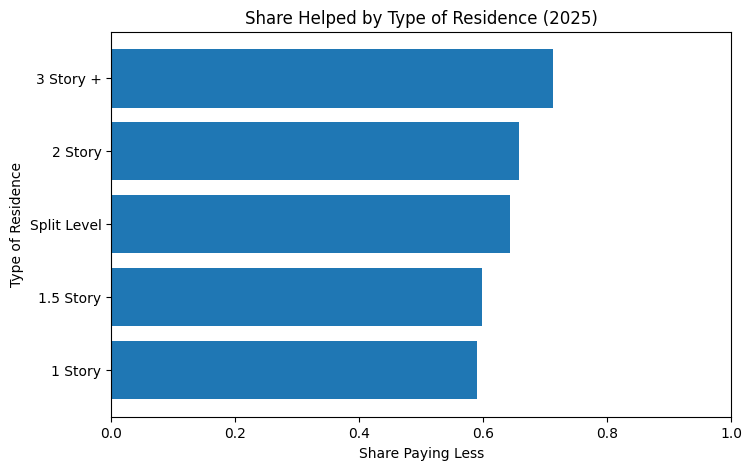

In [ ]:
# Based on the diagnose output, we can see that:
# Plot 1 and Plot 2 already use a fixed grouping variable (value decile),
# and Plot 3 already uses a fixed analysis variable (pct_change).
# Plot 4 is different because it is a subgroup comparison plot.
# Based on the diagnostic output, type_of_residence is usable:
# it has very low missingness and meaningful category values.
# Plot 4: Share helped by type of residence

res_df = dist_2025_df.dropna(subset=["type_of_residence"]).copy()

res_summary = (
    res_df.groupby("type_of_residence")
    .agg(
        n_parcels=("pin", "count"),
        share_helped=("helped_2025", "mean"),
        share_hurt=("hurt_2025", "mean"),
        mean_tax_diff=("tax_diff_2025", "mean"),
        median_tax_diff=("tax_diff_2025", "median"),
        mean_pct_change=("pct_change_2025", "mean"),
        median_pct_change=("pct_change_2025", "median")
    )
    .reset_index()
    .sort_values("share_helped", ascending=True)
)

print(res_summary)

plt.figure(figsize=(8, 5))
plt.barh(res_summary["type_of_residence"].astype(str), res_summary["share_helped"])
plt.xlabel("Share Paying Less")
plt.ylabel("Type of Residence")
plt.title("Share Helped by Type of Residence (2025)")
plt.xlim(0, 1)
plt.show()

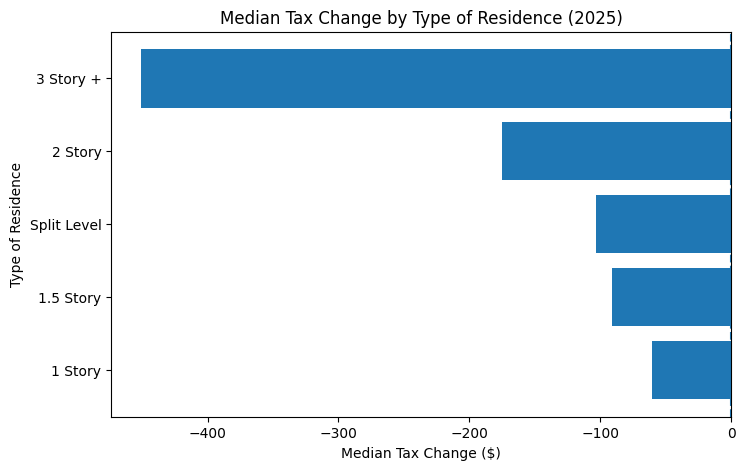

In [ ]:
# Plot 5 - the median tax change by type of residence subgroup (also a companion plot for Plot 4)
plt.figure(figsize=(8, 5))
plt.barh(res_summary["type_of_residence"].astype(str), res_summary["median_tax_diff"])
plt.axvline(0, linestyle="--")
plt.xlabel("Median Tax Change ($)")
plt.ylabel("Type of Residence")
plt.title("Median Tax Change by Type of Residence (2025)")
plt.show()

   building_sqft_quintile  n_parcels  share_helped  median_tax_diff
0                       1     220480      0.625694       -65.472653
1                       2     220669      0.615478       -86.386756
2                       3     219689      0.603134       -96.414095
3                       4     220343      0.633363      -150.961890
4                       5     220164      0.652704      -267.382477


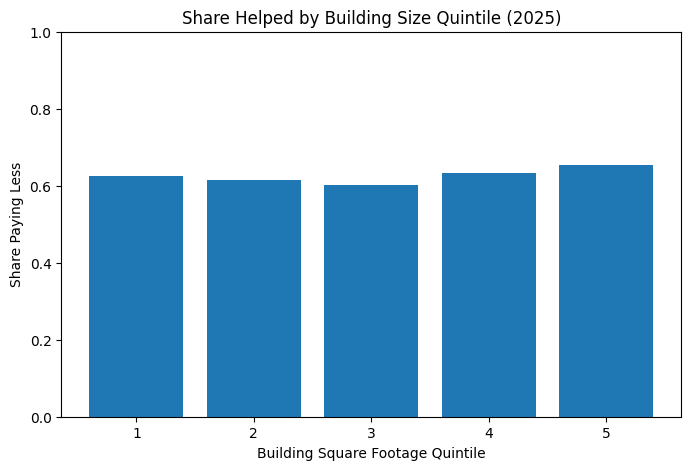

In [ ]:
# Directly test the “bigger house” claim (since from our slides, there is a proposal that "people with bigger houses benefit more")
# Plot 6: Share helped by building square footage quintile

size_df = dist_2025_df.dropna(subset=["building_sqft"]).copy()
size_df = size_df[size_df["building_sqft"] > 0].copy()

size_df["building_sqft_quintile"] = (
    pd.qcut(
        size_df["building_sqft"],
        q=5,
        labels=False,
        duplicates="drop"
    ) + 1
)

size_summary = (
    size_df.groupby("building_sqft_quintile")
    .agg(
        n_parcels=("pin", "count"),
        share_helped=("helped_2025", "mean"),
        median_tax_diff=("tax_diff_2025", "median")
    )
    .reset_index()
)

print(size_summary)

plt.figure(figsize=(8, 5))
plt.bar(size_summary["building_sqft_quintile"], size_summary["share_helped"])
plt.xlabel("Building Square Footage Quintile")
plt.ylabel("Share Paying Less")
plt.title("Share Helped by Building Size Quintile (2025)")
plt.ylim(0, 1)
plt.xticks(size_summary["building_sqft_quintile"])
plt.show()

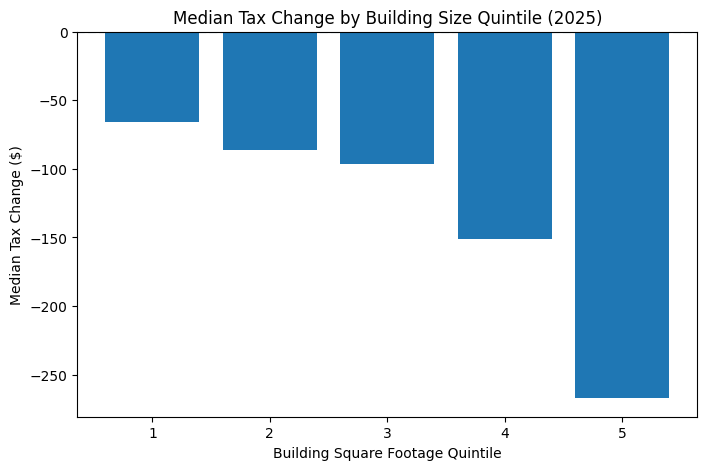

In [ ]:
# Plot 7: Median tax change by building square footage quintile

plt.figure(figsize=(8, 5))
plt.bar(size_summary["building_sqft_quintile"], size_summary["median_tax_diff"])
plt.axhline(0, linestyle="--")
plt.xlabel("Building Square Footage Quintile")
plt.ylabel("Median Tax Change ($)")
plt.title("Median Tax Change by Building Size Quintile (2025)")
plt.xticks(size_summary["building_sqft_quintile"])
plt.show()

In [ ]:
# Export the outcome data for Streamlit using
dist_2025_df.to_csv("dist_2025_df.csv", index=False)

NameError: name 'dist_2025_df' is not defined